This snippet handles the complete data ingestion, preprocessing, missing value imputation, and feature engineering pipeline:

* **Library & Dataset Loading:** Imports core data science and machine learning packages, loads the customer segmentation dataset from Hugging Face, and strips leading/trailing spaces from column headers.
* **Missing Value Imputation:** Fills missing categorical values (`Ever_Married`, `Graduated`, `Profession`) with the label `'Unknown'` and imputes missing numerical columns (`Work_Experience`, `Family_Size`) using median values.
* **Feature Engineering:** Creates derived ratio features (`Experience_Age_Ratio`), binary flags (`Is_Married`, `Graduated_Int`), and numerical interaction terms (`Age_Married_Interact`, `Age_Graduated_Interact`).
* **Binning & Categorical Formations:** Discretizes `Age` into four life stages (`Age_Group`) and `Work_Experience` into career levels (`Career_Stage`), while combining marital status and profession into a joint category (`Married_Profession`).
* **Conditional Ratios:** Checks for `Family_Size` presence to dynamically generate household age density (`Age_Per_Family_Member`).

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Load dataset from Hugging Face and convert to pandas DataFrame
ds = load_dataset("jason1966/abisheksudarshan_customer-segmentation")
df = ds['train'].to_pandas()
df.columns = [c.strip() for c in df.columns]

# Impute missing values for categorical and numerical features
df['Ever_Married'] = df['Ever_Married'].fillna('Unknown')
df['Graduated'] = df['Graduated'].fillna('Unknown')
df['Profession'] = df['Profession'].fillna('Unknown')
df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())
if 'Family_Size' in df.columns:
    df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].median())

# Feature engineering: create interaction terms, ratios, and binned features
df_fe = df.copy()

df_fe['Experience_Age_Ratio'] = df_fe['Work_Experience'] / df_fe['Age']
df_fe['Is_Married'] = (df_fe['Ever_Married'] == 'Yes').astype(int)
df_fe['Age_Married_Interact'] = df_fe['Age'] * df_fe['Is_Married']
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=[0, 25, 40, 60, 100], labels=['Young', 'Adult', 'Mid_Age', 'Senior'])
df_fe['Career_Stage'] = pd.cut(df_fe['Work_Experience'], bins=[-1, 1, 5, 10, 50], labels=['Junior', 'Mid', 'Senior', 'Veteran'])


df_fe['Graduated_Int'] = (df_fe['Graduated'] == 'Yes').astype(int)
df_fe['Age_Graduated_Interact'] = df_fe['Age'] * df_fe['Graduated_Int']
# df_fe['Graduated_Profession'] = df_fe['Graduated'].astype(str) + "_" + df_fe['Profession'].astype(str)
df_fe['Married_Profession'] = df_fe['Ever_Married'].astype(str) + "_" + df_fe['Profession'].astype(str)

if 'Family_Size' in df_fe.columns:
    df_fe['Age_Per_Family_Member'] = df_fe['Age'] / (df_fe['Family_Size'] + 1)


This snippet manages feature matrix construction, target encoding, categorical dummy transformation, stratified dataset partitioning, and feature scaling:

* **Feature & Target Extraction:** Identifies and drops target and identifier columns (`Spending_Score`, `Customer_ID`, `ID`) to form the feature matrix `X`, storing raw target labels in `y_raw`.
* **Label Encoding:** Encodes categorical target values into integer class indices using `LabelEncoder()`.
* **Categorical One-Hot Encoding:** Automatically detects object and categorical data types using `select_dtypes()` and converts them into binary dummy columns with `pd.get_dummies(..., drop_first=True)` to prevent multicollinearity.
* **Stratified Train-Test Split:** Splices the data into an 80% training set and a 20% test set while preserving class distributions using `stratify=y`.
* **Standardization & Leakage Prevention:** Centers and scales all integer and float features to unit variance using `StandardScaler()`, fitting strictly on `X_train` and applying the learned parameters to transform `X_test`.

In [21]:

# Separate features (X) and target variable (y)
features_to_drop = ['Spending_Score', 'Customer_ID', 'ID']
features_to_drop = [col for col in features_to_drop if col in df_fe.columns]

X = df_fe.drop(columns=features_to_drop)
y_raw = df_fe['Spending_Score']

# Encode target categorical labels into integer values
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

# One-hot encode categorical feature columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split data into train and test sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical features
num_cols = X_encoded.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


This snippet instantiates four distinct machine learning classifiers to serve as base estimators for an ensemble model:

* **Random Forest Classifier (`rf_model`):** Standard bagging ensemble utilizing 150 decision trees restricted to a max depth of 10 for variance reduction.
* **Extra Trees Classifier (`et_model`):** Extremely Randomized Trees model using 150 trees with random split thresholds to increase randomness and lower model variance.
* **XGBoost Classifier (`xgb_model`):** Gradient boosting model configured with 150 estimators, a low learning rate of 0.03, max depth of 5, 80% row/column subsampling, and multiclass log loss.
* **LightGBM Classifier (`lgb_model`):** Fast gradient boosting tree framework configured with matching hyperparameters (150 estimators, 0.03 learning rate, depth of 5) and suppressed logging output.

In [22]:

# Initialize base models for ensemble
rf_model = RandomForestClassifier(
    n_estimators=150, max_depth=10, random_state=42, n_jobs=-1
)

et_model = ExtraTreesClassifier(
    n_estimators=150, max_depth=10, random_state=42, n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=150, learning_rate=0.03, max_depth=5, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='mlogloss'
)

lgb_model = LGBMClassifier(
    n_estimators=150, learning_rate=0.03, max_depth=5, random_state=42, verbose=-1
)


This snippet constructs, trains, evaluates, and visualizes a standalone Hard Voting Ensemble classifier:

* **Ensemble Construction & Training:** Instantiates a `VotingClassifier` aggregating four base estimators (`RandomForest`, `ExtraTrees`, `XGBoost`, `LightGBM`) using majority-rule voting (`voting='hard'`), then fits the model across `X_train` and `y_train`.
* **Prediction & Accuracy Calculation:** Predicts class labels (`y_pred_hard`) on the unseen test set (`X_test`) and calculates overall classification accuracy via `accuracy_score()`.
* **Detailed Performance Evaluation:** Prints formatted result banners and displays a comprehensive class-level classification report (`precision`, `recall`, `F1-score`) mapped to decoded class labels (`target_names`).
* **Confusion Matrix Visualization:** Plots an annotated single-axis Seaborn heatmap (`cmap='Blues'`) showing predicted versus actual class distributions, formatted with integer counts (`fmt='d'`) and the accuracy score in the plot title.


     HARD VOTING ENSEMBLE RESULTS (Accuracy: 0.8209)     
              precision    recall  f1-score   support

     Average       0.64      0.91      0.75       395
        High       0.73      0.61      0.67       243
         Low       0.96      0.84      0.89       976

    accuracy                           0.82      1614
   macro avg       0.78      0.79      0.77      1614
weighted avg       0.85      0.82      0.83      1614



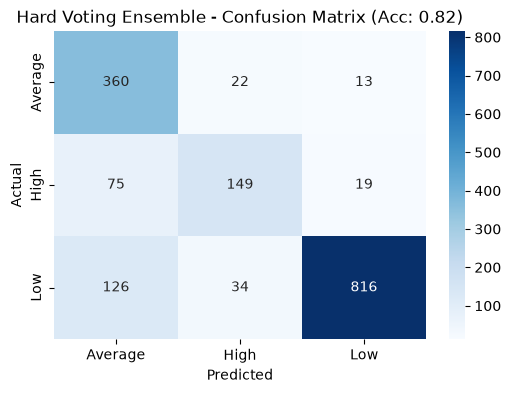

In [23]:

# Build Hard Voting Ensemble Classifier
voting_hard_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('et', et_model),
        ('xgb', xgb_model),
        ('lgbm', lgb_model)
    ],
    voting='hard'
)

# Train Hard Voting Ensemble model
voting_hard_model.fit(X_train, y_train)

# Evaluate model predictions
y_pred_hard = voting_hard_model.predict(X_test)

target_names = target_encoder.classes_
acc_hard = accuracy_score(y_test, y_pred_hard)

print("\n" + "="*55)
print(f"     HARD VOTING ENSEMBLE RESULTS (Accuracy: {acc_hard:.4f})     ")
print("="*55)
print(classification_report(y_test, y_pred_hard, target_names=target_names))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_hard), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Hard Voting Ensemble - Confusion Matrix (Acc: {acc_hard:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

This snippet defines a robust inference function (`predict_customer_spending_score`) designed to handle both single-record dictionaries and batch DataFrames, with explicit support for missing or omitted input features:

* **Flexible Data Ingestion:** Converts dictionary inputs into single-row DataFrames or copies existing DataFrames while safely checking global dataset fallbacks for continuous medians (`Work_Experience`, `Family_Size`).
* **Feature Engineering Replication:** Automatically constructs all ratio, binary, interaction, binned (`Age_Group`, `Career_Stage`), and composite string features on new inference records to match the training pipeline architecture.
* **Schema Alignment & Omitted Feature Handling:** One-hot encodes present categorical columns and uses `df_encoded.reindex(columns=X_encoded.columns, fill_value=0)` to align features with the training set—automatically zero-filling dummy columns for omitted features (e.g., `Var_1`).
* **Scaling & Decoded Predictions:** Standardizes numerical columns via `scaler.transform()`, generates predicted numerical indices using the specified ensemble model, and decodes them back to original class strings via `target_encoder.inverse_transform()`.

In [24]:
def predict_customer_spending_score(customer_info, model=voting_hard_model):
    """
    Predicts the Spending_Score for customer(s) using the trained hard voting model.
    Omitting features like 'Var_1' or 'Family_Size' is supported.
    """
    if isinstance(customer_info, dict):
        df_input = pd.DataFrame([customer_info])
    else:
        df_input = customer_info.copy()

    # 1. Handle missing values with fallbacks
    df_input['Ever_Married'] = df_input['Ever_Married'].fillna('Unknown') if 'Ever_Married' in df_input.columns else 'Unknown'
    df_input['Graduated'] = df_input['Graduated'].fillna('Unknown') if 'Graduated' in df_input.columns else 'Unknown'
    df_input['Profession'] = df_input['Profession'].fillna('Unknown') if 'Profession' in df_input.columns else 'Unknown'
    
    work_exp_median = df['Work_Experience'].median() if 'df' in globals() else 0
    df_input['Work_Experience'] = df_input['Work_Experience'].fillna(work_exp_median) if 'Work_Experience' in df_input.columns else work_exp_median

    family_size_median = df['Family_Size'].median() if ('df' in globals() and 'Family_Size' in df.columns) else 1
    df_input['Family_Size'] = df_input['Family_Size'].fillna(family_size_median) if 'Family_Size' in df_input.columns else family_size_median

    # 2. Apply Feature Engineering
    df_fe_input = df_input.copy()
    
    df_fe_input['Experience_Age_Ratio'] = df_fe_input['Work_Experience'] / df_fe_input['Age']
    df_fe_input['Is_Married'] = (df_fe_input['Ever_Married'] == 'Yes').astype(int)
    df_fe_input['Age_Married_Interact'] = df_fe_input['Age'] * df_fe_input['Is_Married']
    
    df_fe_input['Age_Group'] = pd.cut(df_fe_input['Age'], bins=[0, 25, 40, 60, 100], labels=['Young', 'Adult', 'Mid_Age', 'Senior'])
    df_fe_input['Career_Stage'] = pd.cut(df_fe_input['Work_Experience'], bins=[-1, 1, 5, 10, 50], labels=['Junior', 'Mid', 'Senior', 'Veteran'])
    
    df_fe_input['Graduated_Int'] = (df_fe_input['Graduated'] == 'Yes').astype(int)
    df_fe_input['Age_Graduated_Interact'] = df_fe_input['Age'] * df_fe_input['Graduated_Int']
    df_fe_input['Married_Profession'] = df_fe_input['Ever_Married'].astype(str) + "_" + df_fe_input['Profession'].astype(str)

    if 'Family_Size' in df_fe_input.columns:
        df_fe_input['Age_Per_Family_Member'] = df_fe_input['Age'] / (df_fe_input['Family_Size'] + 1)

    # 3. Drop unneeded metadata features if present
    drop_cols = ['Spending_Score', 'Customer_ID', 'ID']
    df_fe_input = df_fe_input.drop(columns=[col for col in drop_cols if col in df_fe_input.columns])

    # 4. Categorical Encoding & Alignment
    cat_cols_input = df_fe_input.select_dtypes(include=['object', 'category']).columns.tolist()
    df_encoded = pd.get_dummies(df_fe_input, columns=cat_cols_input, drop_first=True)

    # Reindex aligns all columns to match training set features, filling absent ones (like Var_1) with 0
    df_aligned = df_encoded.reindex(columns=X_encoded.columns, fill_value=0)

    # 5. Scale Numerical Features
    df_aligned[num_cols] = scaler.transform(df_aligned[num_cols])

    # 6. Predict using Hard Voting Ensemble and Inverse Transform
    y_pred_numeric = model.predict(df_aligned)
    y_pred_label = target_encoder.inverse_transform(y_pred_numeric)

    return y_pred_label

This snippet demonstrates real-world inference testing without optional dataset features (omitting `Var_1`):

* **Minimal Dictionary Payload:** Defines a single customer profile (`sample_customer`) containing key demographic and career fields while omitting optional columns like `Var_1`.
* **Inference Execution:** Passes the incomplete record into `predict_customer_spending_score()`, where missing columns are automatically zero-imputed during feature alignment (`reindex`).
* **Formatted Output:** Generates and displays the final decoded spending score class prediction (`prediction[0]`) using the trained `voting_hard_model`.

In [25]:
sample_customer = {
    'Gender': 'Male',
    'Ever_Married': 'No',
    'Age': 22,
    'Graduated': 'No',
    'Profession': 'Healthcare',
    'Work_Experience': 1,
    'Family_Size': 4
}

prediction = predict_customer_spending_score(sample_customer, model=voting_hard_model)
print(f"Predicted Spending Score (Hard Voting): {prediction[0]}")

Predicted Spending Score (Hard Voting): Low
